# 1. Setup

## 1.1 Import and load data

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import statsmodels.api as sm
import numpy as np
from scipy import stats

In [3]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = Path('..') / 'data' / 'processed' / 'master_occupations.csv'
data = pd.read_csv(DATA_PATH, dtype={'OCC_CODE': str})

In [12]:
wage_data = data.dropna(subset=[
    'wage_change_pct_19_24',
    'wage_change_pct_19_22',
    'wage_change_pct_22_24'
]).copy()

## 1.2 Understand data structure and format

In [36]:
print(f'Total occupations in master table:        {len(data)}')
print(f'Occupations with complete wage data:      {len(wage_data)}')
print(f'Dropped due to missing wage outcomes:     {len(data) - len(wage_data)}')

Total occupations in master table:        655
Occupations with complete wage data:      655
Dropped due to missing wage outcomes:     0


In [37]:
print(f'\nWage change summary (2019 to 2024):')
print(wage_data['wage_change_pct_19_24'].describe().round(2))


Wage change summary (2019 to 2024):
count    655.00
mean       4.02
std       10.72
min      -42.91
25%       -1.43
50%        3.28
75%        9.08
max      172.94
Name: wage_change_pct_19_24, dtype: float64


In [38]:
print(f'\nWage change summary (2019 to 2022):')
print(wage_data['wage_change_pct_19_22'].describe().round(2))


Wage change summary (2019 to 2022):
count    655.00
mean       2.82
std        8.04
min      -36.55
25%       -1.89
50%        2.30
75%        6.59
max       70.57
Name: wage_change_pct_19_22, dtype: float64

Wage change summary (2022 to 2024):
count    655.00
mean       1.24
std        6.78
min      -51.74
25%       -2.21
50%        1.01
75%        4.77
max       93.01
Name: wage_change_pct_22_24, dtype: float64


In [39]:
print(f'\nWage change summary (2022 to 2024):')
print(wage_data['wage_change_pct_22_24'].describe().round(2))


Wage change summary (2022 to 2024):
count    655.00
mean       1.24
std        6.78
min      -51.74
25%       -2.21
50%        1.01
75%        4.77
max       93.01
Name: wage_change_pct_22_24, dtype: float64


# 2 Statistical Validation

## 2.1 Wage Change: UAIOE Full Period (2019 to 2024)

In [21]:
X_full = sm.add_constant(wage_data['UAIOE'])
y_full = wage_data['wage_change_pct_19_24']

model_wage_full = sm.OLS(y_full, X_full).fit()
print(model_wage_full.summary())

                              OLS Regression Results                             
Dep. Variable:     wage_change_pct_19_24   R-squared:                       0.120
Model:                               OLS   Adj. R-squared:                  0.119
Method:                    Least Squares   F-statistic:                     89.05
Date:                   Tue, 28 Apr 2026   Prob (F-statistic):           6.64e-20
Time:                           23:59:25   Log-Likelihood:                -2440.5
No. Observations:                    655   AIC:                             4885.
Df Residuals:                        653   BIC:                             4894.
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0171 

In [27]:
# Print key metrics cleanly

print(f'  Coefficient (UAIOE): {model_wage_full.params.iloc[1]:.4f}')
print(f'  R²:                  {model_wage_full.rsquared:.4f}')
print(f'  Adjusted R²:         {model_wage_full.rsquared_adj:.4f}')
print(f'  p-value (UAIOE):     {model_wage_full.pvalues.iloc[1]:.4f}')
print(f'  F-statistic:         {model_wage_full.fvalue:.4f}')
print(f'  N observations:      {int(model_wage_full.nobs)}')
print()
sig = 'significant' if model_wage_full.pvalues['UAIOE'] < 0.05 else 'NOT significant'
direction = 'positive' if model_wage_full.params['UAIOE'] > 0 else 'negative'
print(f'  Result: {sig} at p<0.05, {direction} relationship')

  Coefficient (UAIOE): -3.7094
  R²:                  0.1200
  Adjusted R²:         0.1187
  p-value (UAIOE):     0.0000
  F-statistic:         89.0521
  N observations:      655

  Result: significant at p<0.05, negative relationship


## 2.2 Interval Models: Pre-GenAI (2019 to 2022) and GenAI Era (2022 to 2024)

In [28]:
X = sm.add_constant(wage_data['UAIOE'])

# Interval 1: 2019→2022 Pre-GenAI
model_wage_1922 = sm.OLS(wage_data['wage_change_pct_19_22'], X).fit()

# Interval 2: 2022→2024 GenAI Era
model_wage_2224 = sm.OLS(wage_data['wage_change_pct_22_24'], X).fit()

In [40]:
print(f'{"":<30} {"2019→2022":>12} {"2022→2024":>12}')
print(f'{"Period":<30} {"Pre-GenAI":>12} {"GenAI Era":>12}')
print('-' * 55)
print(f'{"Coefficient (UAIOE)":<30} '
      f'{model_wage_1922.params["UAIOE"]:>12.4f} '
      f'{model_wage_2224.params["UAIOE"]:>12.4f}')
print(f'{"R²":<30} '
      f'{model_wage_1922.rsquared:>12.4f} '
      f'{model_wage_2224.rsquared:>12.4f}')
print(f'{"Adjusted R²":<30} '
      f'{model_wage_1922.rsquared_adj:>12.4f} '
      f'{model_wage_2224.rsquared_adj:>12.4f}')
print(f'{"p-value":<30} '
      f'{model_wage_1922.pvalues["UAIOE"]:>12.4f} '
      f'{model_wage_2224.pvalues["UAIOE"]:>12.4f}')
print(f'{"N observations":<30} '
      f'{int(model_wage_1922.nobs):>12} '
      f'{int(model_wage_2224.nobs):>12}')
print()
stronger = 'GenAI Era (2022 to 2024)' if model_wage_2224.rsquared > model_wage_1922.rsquared else '2019→2022 Pre-GenAI'
print(f'Effect stronger in: {stronger}')

                                  2019→2022    2022→2024
Period                            Pre-GenAI    GenAI Era
-------------------------------------------------------
Coefficient (UAIOE)                 -2.4730      -1.1594
R²                                   0.0948       0.0293
Adjusted R²                          0.0934       0.0278
p-value                              0.0000       0.0000
N observations                          655          655

Effect stronger in: 2019→2022 Pre-GenAI


# Visual Validation

## Scatter Plots: UAIOE and Wage Change All Periods

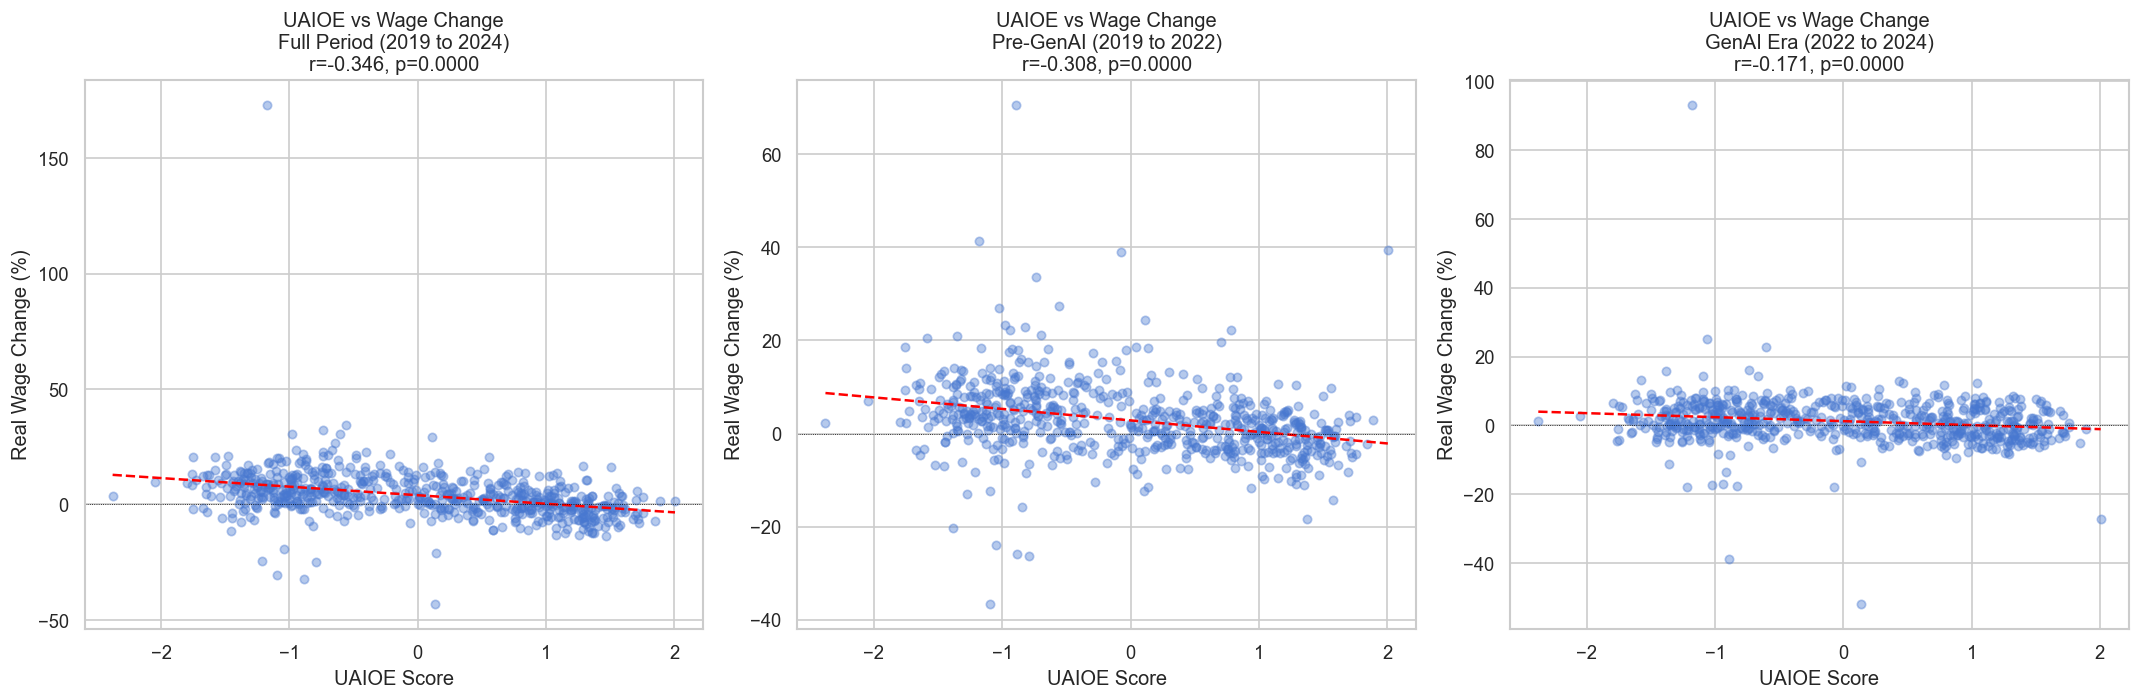

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

periods = [
    ('wage_change_pct_19_24', 'Full Period (2019 to 2024)'),
    ('wage_change_pct_19_22', 'Pre-GenAI (2019 to 2022)'),
    ('wage_change_pct_22_24', 'GenAI Era (2022 to 2024)')
]

for ax, (col, title) in zip(axes, periods):
    plot_df = wage_data.dropna(subset=[col])
    ax.scatter(plot_df['UAIOE'], plot_df[col], alpha=0.4, s=25)
    m, b, r, p, _ = stats.linregress(plot_df['UAIOE'], plot_df[col])
    x_line = np.linspace(plot_df['UAIOE'].min(), plot_df['UAIOE'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5, linestyle='--')
    ax.axhline(0, color='black', linewidth=0.5, linestyle=':')

    ax.set_title(f'UAIOE vs Wage Change\n{title}\nr={r:.3f}, p={p:.4f}')
    ax.set_xlabel('UAIOE Score')
    ax.set_ylabel('Real Wage Change (%)')

plt.tight_layout()
plt.show()

## 3. Pearson correlations: UAIOE and wage change

In [64]:
for col, label in periods:
    df_sub = wage_data.dropna(subset=[col])
    r, p = stats.pearsonr(df_sub['UAIOE'], df_sub[col])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'  {label:<30} r={r:.4f}  p={p:.4f}  {sig}')

  Full Period (2019 to 2024)     r=-0.3464  p=0.0000  ***
  Pre-GenAI (2019 to 2022)       r=-0.3079  p=0.0000  ***
  GenAI Era (2022 to 2024)       r=-0.1711  p=0.0000  ***
